# H-001 · S2 Universes Discovery + Baseline Backtest

This notebook runs the H-001 workflow end-to-end:

1. Sector-only candidate screening (A/B/C) at fixed calendar `RESEARCH_IS_END`
2. Manual keep gate (`KEEP_PAIR_IDS`)
3. Export locked pairs artifacts (`s2_pairs_{A,B,C}_1d.csv`)
4. Research-IS trad-z diagnostics (per-pair trades, cost drag, Sharpe/DD, rolling ADF)

Evaluation uses **research IS only** (`date <= RESEARCH_IS_END`). Do not score sealed OOS here. Costs and the baseline simulator live in `strategies.s2_coint` (`costs.py`, `baseline.py`, `metrics.py`). Overlay check: compound IS daily book returns to S1 Monday–Monday weeks vs `s1_period_returns.parquet` (from `08_oos_tearsheet.ipynb`).

**Run order:** run this notebook **first**. It creates/updates the locked pair artifacts (`s2_pairs_{A,B,C}_1d.csv`).

Then run `01_data/data_files/s2_coint/s2_pair_panel.ipynb` **second** to build train/full panels from those locked pair artifacts.

## 0. Imports & Config

In [9]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from data.ingestion.equity_fetcher import fetch_ohlcv
from data.processing.feature_implementation.cointegration import COINT_PVALUE
from data.processing.s2_coint_store import build_pair_panel, screen_pair_cointegration
from data.processing.s2_universe import load_s2_universes, ticker_venue_key
from strategies.s2_coint.baseline import (
    BETA_COLUMN,
    ENTRY_Z,
    EXIT_Z,
    USE_HEDGE_RATIO_SIZING,
    clip_ohlc_to_is,
)
from strategies.s2_coint.metrics import (
    diagnose_locked_panel,
    load_s1_period_returns,
    universe_is_metrics,
)

NOTEBOOK_DIR = os.path.abspath(os.getcwd())
DATA_DIR = os.path.join(ROOT, "01_data", "data_files", "s2_coint")
UNIVERSES_CSV = os.path.join(DATA_DIR, "s2_universes.csv")
UNIVERSE_LABELS = ("A", "B", "C")
S1_RETURNS_PATH = os.path.join(ROOT, "01_data", "data_files", "s1_equities", "s1_period_returns.parquet")

FETCH_START = "1990-01-01"
END_DATE = None
RESEARCH_IS_END = {
    "A": "2020-12-31",
    "B": "2022-12-31",
    "C": "2021-12-31",
}

COINT_PVALUE_THRESHOLD = 0.05
OLS_WINDOW = 252
Z_WINDOW = 60
HL_WINDOW = 252
ADF_PVALUE_THRESHOLD = COINT_PVALUE

SIM_KW = dict(
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    beta_column=BETA_COLUMN,
    use_hedge_ratio_sizing=USE_HEDGE_RATIO_SIZING,
)

# Sector-only candidate map (manual universe design)
SECTOR_PAIR_MAP = {
    "A": [
        ("AUDUSD=X", "NZDUSD=X"),
        ("EURUSD=X", "GBPUSD=X"),
        ("USDCHF=X", "USDJPY=X"),
        ("EURUSD=X", "USDCHF=X"),
    ],
    "B": [
        ("BTC-USD", "ETH-USD"),
        ("BTC-USD", "BNB-USD"),
        ("ETH-USD", "BNB-USD"),
        ("ETH-USD", "SOL-USD"),
        ("BTC-USD", "SOL-USD"),
        ("BNB-USD", "SOL-USD"),
    ],
    "C": [
        ("0939.HK", "1288.HK"),
        ("0939.HK", "1398.HK"),
        ("0939.HK", "3328.HK"),
        ("0939.HK", "3988.HK"),
        ("1288.HK", "1398.HK"),
        ("1288.HK", "3328.HK"),
        ("1288.HK", "3988.HK"),
        ("1398.HK", "3328.HK"),
        ("1398.HK", "3988.HK"),
        ("3328.HK", "3988.HK"),
        ("8306.T", "8316.T"),
        ("8306.T", "8411.T"),
        ("8316.T", "8411.T"),
        ("0386.HK", "0857.HK"),
        ("0386.HK", "0883.HK"),
        ("0857.HK", "0883.HK"),
    ],
}

# Manual keep gate: only these pairs are exported/used. Update intentionally.
KEEP_PAIR_IDS = {
    "A": [],
    "B": [],
    "C": [
        "1398.HK|0939.HK",
        "1288.HK|3328.HK",
        "8306.T|8316.T"
    ],
}


def pairs_csv_path(label: str) -> str:
    return os.path.join(DATA_DIR, f"s2_pairs_{label}_1d.csv")


def panel_train_path(label: str) -> str:
    return os.path.join(DATA_DIR, f"s2_panel_{label}_1d_train.parquet")


def panel_full_path(label: str) -> str:
    return os.path.join(DATA_DIR, f"s2_panel_{label}_1d_full.parquet")


## 1. Load universes and fetch OHLCV

In [10]:
universes = load_s2_universes(UNIVERSES_CSV)
assert len(universes) == 3

ohlc_by_universe: dict[str, dict[str, pd.DataFrame]] = {}
closes_by_universe: dict[str, dict[str, pd.Series]] = {}

for label, tickers in zip(UNIVERSE_LABELS, universes):
    is_asian = label == "C"
    ohlc: dict[str, pd.DataFrame] = {}
    closes: dict[str, pd.Series] = {}
    print(f"\n=== Universe {label} ===")
    for ticker in tickers:
        panel = fetch_ohlcv(
            ticker,
            start_date=FETCH_START,
            end_date=END_DATE,
            isAsian=is_asian,
        )
        if panel is None or panel.empty:
            print(f"WARNING: no OHLCV for {ticker} ({label})")
            continue
        frame = (
            panel.sort_values("date")
            .drop_duplicates("date", keep="last")
            .set_index("date")[["open", "high", "low", "close"]]
            .astype(float)
        )
        frame.index = pd.to_datetime(frame.index)
        frame = frame.dropna(subset=["close"])
        if frame.empty:
            print(f"WARNING: no valid closes for {ticker} ({label})")
            continue
        ohlc[ticker] = frame
        closes[ticker] = frame["close"].copy()
        print(
            f"{ticker:12} bars={len(frame):5d} venue={ticker_venue_key(ticker)} "
            f"[{frame.index.min().date()} .. {frame.index.max().date()}]"
        )
    ohlc_by_universe[label] = ohlc
    closes_by_universe[label] = closes


=== Universe A ===
AUDUSD=X     bars= 5269 venue=FX [2006-05-16 .. 2026-08-18]
NZDUSD=X     bars= 5894 venue=FX [2003-12-01 .. 2026-08-18]
EURUSD=X     bars= 5893 venue=FX [2003-12-01 .. 2026-08-18]
GBPUSD=X     bars= 5905 venue=FX [2003-12-01 .. 2026-08-18]
USDCHF=X     bars= 5959 venue=FX [2003-09-17 .. 2026-08-18]
USDJPY=X     bars= 7727 venue=FX [1996-10-30 .. 2026-08-18]

=== Universe B ===
BTC-USD      bars= 4354 venue=CRYPTO [2014-09-17 .. 2026-08-18]
ETH-USD      bars= 3205 venue=CRYPTO [2017-11-09 .. 2026-08-18]
SOL-USD      bars= 2322 venue=CRYPTO [2020-04-10 .. 2026-08-18]
BNB-USD      bars= 3205 venue=CRYPTO [2017-11-09 .. 2026-08-18]

=== Universe C ===
0939.HK      bars= 5129 venue=HK [2005-10-27 .. 2026-08-18]
1398.HK      bars= 4880 venue=HK [2006-10-27 .. 2026-08-18]
3988.HK      bars= 4985 venue=HK [2006-06-01 .. 2026-08-18]
1288.HK      bars= 3964 venue=HK [2010-07-16 .. 2026-08-18]
3328.HK      bars= 5216 venue=HK [2005-06-23 .. 2026-08-18]
8306.T       bars= 5146 

## 2. Sector-only screening (fixed `RESEARCH_IS_END`)

In [11]:
def normalize_pair(a: str, b: str) -> tuple[str, str]:
    left, right = sorted((a, b))
    return left, right


def build_sector_candidates(label: str, available: set[str]) -> list[tuple[str, str]]:
    if label not in SECTOR_PAIR_MAP:
        raise KeyError(f"missing sector map for universe {label}")
    out: list[tuple[str, str]] = []
    for a, b in SECTOR_PAIR_MAP[label]:
        if a not in available or b not in available:
            print(f"SKIP missing ticker pair in {label}: {a}|{b}")
            continue
        if ticker_venue_key(a) != ticker_venue_key(b):
            raise ValueError(f"cross-venue pair blocked in sector map {label}: {a}|{b}")
        out.append(normalize_pair(a, b))
    return sorted(set(out))


screened_by_universe: dict[str, pd.DataFrame] = {}
passing_by_universe: dict[str, pd.DataFrame] = {}

for label, closes in closes_by_universe.items():
    candidates = build_sector_candidates(label, set(closes.keys()))
    is_end = pd.Timestamp(RESEARCH_IS_END[label])
    print(f"\n=== Universe {label} sector candidates={len(candidates)} is_end={is_end.date()} ===")

    screened = screen_pair_cointegration(
        closes,
        candidates,
        is_end=is_end,
        ols_window=OLS_WINDOW,
        pvalue_threshold=COINT_PVALUE_THRESHOLD,
    ).sort_values(["eligible", "pvalue"], ascending=[False, True], kind="mergesort").reset_index(drop=True)

    screened_by_universe[label] = screened
    eligible = screened.loc[screened["eligible"]].copy()
    passing = eligible.loc[eligible["pvalue"] < COINT_PVALUE_THRESHOLD].copy()
    passing_by_universe[label] = passing

    n_candidates = len(screened)
    n_ineligible = int((~screened["eligible"]).sum())
    n_eg_fail = int((eligible["pvalue"] >= COINT_PVALUE_THRESHOLD).sum())
    n_pass = len(passing)

    display(screened)
    print(
        f"diagnostics: n_candidates={n_candidates} n_ineligible={n_ineligible} "
        f"n_eg_fail={n_eg_fail} n_pass={n_pass}"
    )


=== Universe A sector candidates=4 is_end=2020-12-31 ===


,pair_id,ticker_y,ticker_x,pvalue,tstat,discovery_half_life,n_is_bars,is_end,eligible
0,NZDUSD=X|AUDUSD=X,NZDUSD=X,AUDUSD=X,0.163407,-2.807191,41.860587,3806,2020-12-31,True
1,EURUSD=X|GBPUSD=X,EURUSD=X,GBPUSD=X,0.368465,-2.310219,25.958663,4425,2020-12-31,True
2,USDCHF=X|EURUSD=X,USDCHF=X,EURUSD=X,0.437666,-2.174275,15.888573,4427,2020-12-31,True
3,USDCHF=X|USDJPY=X,USDCHF=X,USDJPY=X,0.573315,-1.913164,28.583009,4480,2020-12-31,True


diagnostics: n_candidates=4 n_ineligible=0 n_eg_fail=4 n_pass=0

=== Universe B sector candidates=6 is_end=2022-12-31 ===


,pair_id,ticker_y,ticker_x,pvalue,tstat,discovery_half_life,n_is_bars,is_end,eligible
0,BNB-USD|ETH-USD,BNB-USD,ETH-USD,0.050159,-3.334543,64.766630,1879,2022-12-31,True
1,BNB-USD|BTC-USD,BNB-USD,BTC-USD,0.164710,-2.803069,115.065345,1879,2022-12-31,True
2,ETH-USD|SOL-USD,ETH-USD,SOL-USD,0.279796,-2.498354,39.896601,996,2022-12-31,True
3,BTC-USD|ETH-USD,BTC-USD,ETH-USD,0.355998,-2.335461,78.102926,1879,2022-12-31,True
4,BTC-USD|SOL-USD,BTC-USD,SOL-USD,0.713037,-1.618458,63.689650,996,2022-12-31,True
5,BNB-USD|SOL-USD,BNB-USD,SOL-USD,0.773883,-1.466308,51.244520,996,2022-12-31,True


diagnostics: n_candidates=6 n_ineligible=0 n_eg_fail=6 n_pass=0

=== Universe C sector candidates=16 is_end=2021-12-31 ===


,pair_id,ticker_y,ticker_x,pvalue,tstat,discovery_half_life,n_is_bars,is_end,eligible
0,1398.HK|0939.HK,1398.HK,0939.HK,0.000020,-5.471811,23.401149,3746,2021-12-31,True
1,1288.HK|1398.HK,1288.HK,1398.HK,0.000360,-4.811375,28.865340,2830,2021-12-31,True
2,1288.HK|0939.HK,1288.HK,0939.HK,0.001582,-4.431802,21.391524,2830,2021-12-31,True
3,1288.HK|3328.HK,1288.HK,3328.HK,0.004029,-4.171372,33.469948,2830,2021-12-31,True
4,3328.HK|3988.HK,3328.HK,3988.HK,0.014253,-3.783615,25.909993,3851,2021-12-31,True
5,3328.HK|1398.HK,3328.HK,1398.HK,0.031316,-3.512348,32.744594,3746,2021-12-31,True
6,3328.HK|0939.HK,3328.HK,0939.HK,0.033451,-3.488258,30.593785,3995,2021-12-31,True
7,0939.HK|3988.HK,0939.HK,3988.HK,0.035760,-3.463619,37.222731,3851,2021-12-31,True
8,8306.T|8316.T,8306.T,8316.T,0.048277,-3.349498,25.302012,4016,2021-12-31,True
9,3988.HK|1288.HK,3988.HK,1288.HK,0.066503,-3.220890,46.324082,2830,2021-12-31,True


diagnostics: n_candidates=16 n_ineligible=0 n_eg_fail=7 n_pass=9


## 3. Manual keep gate and locked pairs export

In [12]:
locked_meta_by_universe: dict[str, pd.DataFrame] = {}
locked_pairs_by_universe: dict[str, list[tuple[str, str]]] = {}

for label in UNIVERSE_LABELS:
    passing = passing_by_universe.get(label, pd.DataFrame())
    keep_ids = KEEP_PAIR_IDS.get(label, [])

    if keep_ids:
        locked = passing.loc[passing["pair_id"].isin(keep_ids)].copy()
        missing = sorted(set(keep_ids) - set(locked["pair_id"]))
        if missing:
            raise ValueError(
                f"universe {label}: KEEP_PAIR_IDS not in eligible passers: {missing}"
            )
    else:
        locked = passing.iloc[0:0].copy()  # explicit manual keep required

    locked = locked.reset_index(drop=True)
    locked_meta_by_universe[label] = locked
    locked_pairs_by_universe[label] = [
        (str(row.ticker_y), str(row.ticker_x)) for row in locked.itertuples(index=False)
    ]

    csv_path = pairs_csv_path(label)
    locked.to_csv(csv_path, index=False)
    print(f"{label}: locked_pairs={len(locked)} saved={csv_path}")
    if not locked.empty:
        display(locked[["pair_id", "pvalue", "n_is_bars", "is_end"]])

A: locked_pairs=0 saved=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s2_coint\s2_pairs_A_1d.csv
B: locked_pairs=0 saved=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s2_coint\s2_pairs_B_1d.csv
C: locked_pairs=3 saved=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s2_coint\s2_pairs_C_1d.csv


,pair_id,pvalue,n_is_bars,is_end
0,1398.HK|0939.HK,0.000020,3746,2021-12-31
1,1288.HK|3328.HK,0.004029,2830,2021-12-31
2,8306.T|8316.T,0.048277,4016,2021-12-31


## 4. Build locked-pair research-IS panels


In [13]:
is_panels: dict[str, pd.DataFrame] = {}

for label in UNIVERSE_LABELS:
    pairs = locked_pairs_by_universe.get(label, [])
    if not pairs:
        is_panels[label] = pd.DataFrame()
        print(f"{label}: no locked pairs; skip panel build")
        continue

    is_end = pd.Timestamp(RESEARCH_IS_END[label])
    ohlc_is = clip_ohlc_to_is(ohlc_by_universe[label], is_end)
    panel = build_pair_panel(
        ohlc_is,
        pairs,
        ols_window=OLS_WINDOW,
        z_window=Z_WINDOW,
        hl_window=HL_WINDOW,
        include_adf_pvalue=True,
        include_variance_jump=False,
    )
    panel = panel.sort_values(["pair_id", "date"]).reset_index(drop=True)
    is_panels[label] = panel
    print(
        f"{label}: pairs={panel['pair_id'].nunique()} is_rows={len(panel)} "
        f"is_end={is_end.date()} (OHLC clipped; no OOS rows)"
    )


A: no locked pairs; skip panel build
B: no locked pairs; skip panel build
C: pairs=3 is_rows=10592 is_end=2021-12-31 (OHLC clipped; no OOS rows)


## 5. Per-pair IS diagnostics

Trade count, median hold, annualized cost drag, Sharpe / max DD, and rolling-ADF summaries. One row per locked pair. Empty universes print an empty schema.


In [14]:
pair_diag_by_universe: dict[str, pd.DataFrame] = {}

for label in UNIVERSE_LABELS:
    panel = is_panels.get(label, pd.DataFrame())
    diag = diagnose_locked_panel(
        panel,
        adf_pvalue_threshold=ADF_PVALUE_THRESHOLD,
        **SIM_KW,
    )
    pair_diag_by_universe[label] = diag
    print(f"Universe {label}  n_pairs={len(diag)}")
    display(diag)


Universe A  n_pairs=0


,pair_id,ticker_y,ticker_x,market_profile,n_entries,n_round_trips,n_open_at_end,median_hold_bars,cost_bps_year,ann_sharpe,max_drawdown,n_days,n_adf,median_adf_p,last_adf_p,pct_adf_lt_threshold,adf_threshold


Universe B  n_pairs=0


,pair_id,ticker_y,ticker_x,market_profile,n_entries,n_round_trips,n_open_at_end,median_hold_bars,cost_bps_year,ann_sharpe,max_drawdown,n_days,n_adf,median_adf_p,last_adf_p,pct_adf_lt_threshold,adf_threshold


Universe C  n_pairs=3


,pair_id,ticker_y,ticker_x,market_profile,n_entries,n_round_trips,n_open_at_end,median_hold_bars,cost_bps_year,ann_sharpe,max_drawdown,n_days,n_adf,median_adf_p,last_adf_p,pct_adf_lt_threshold,adf_threshold
0,1288.HK|3328.HK,1288.HK,3328.HK,C_HK_IBKR,43,42,1,28.0,439.306931,-0.480647,-0.405549,2828,2328,0.302422,0.087961,0.113832,0.05
1,1398.HK|0939.HK,1398.HK,0939.HK,C_HK_IBKR,54,54,0,24.0,421.615385,-0.476618,-0.497258,3744,3244,0.194580,0.168227,0.293157,0.05
2,8306.T|8316.T,8306.T,8316.T,C_JP_IBKR,68,67,1,24.0,271.210762,-0.082521,-0.262648,4014,3514,0.231685,0.325532,0.181559,0.05


## 6. Rolling ADF paths (research IS)

Panel `adf_pvalue` from `build_pair_panel` (`compute_coint_metrics`). Horizontal line is `ADF_PVALUE_THRESHOLD` (library `COINT_PVALUE`, not the discovery EG cutoff).


A: no rolling ADF series
B: no rolling ADF series


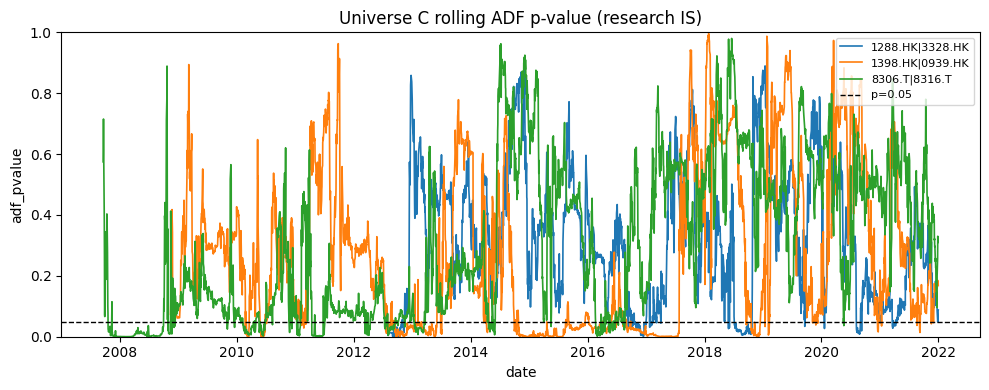

In [15]:
for label in UNIVERSE_LABELS:
    panel = is_panels.get(label, pd.DataFrame())
    if panel.empty or "adf_pvalue" not in panel.columns:
        print(f"{label}: no rolling ADF series")
        continue
    fig, ax = plt.subplots(figsize=(10, 4))
    plotted = False
    for pair_id, g in panel.groupby("pair_id", sort=False):
        g = g.sort_values("date")
        ax.plot(pd.to_datetime(g["date"]), g["adf_pvalue"], label=str(pair_id), lw=1.2)
        plotted = True
    if not plotted:
        print(f"{label}: no rolling ADF series")
        plt.close(fig)
        continue
    ax.axhline(ADF_PVALUE_THRESHOLD, color="black", ls="--", lw=1, label=f"p={ADF_PVALUE_THRESHOLD}")
    ax.set_title(f"Universe {label} rolling ADF p-value (research IS)")
    ax.set_ylabel("adf_pvalue")
    ax.set_xlabel("date")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylim(0.0, 1.0)
    fig.tight_layout()
    plt.show()


## 7. Universe IS book summary

Equal-weight combination of locked pairs on research IS only. Use this together with §5 to see whether a universe is one live pair plus dead weight. `corr_to_s1` is an overlay check on Monday–Monday weeks inside C research IS (missing S1 parquet → NaN).


In [16]:
s1_weekly = load_s1_period_returns(S1_RETURNS_PATH)
c_is_end = pd.Timestamp(RESEARCH_IS_END["C"])
if not s1_weekly.empty:
    s1_weekly = s1_weekly.loc[s1_weekly.index <= c_is_end]
if s1_weekly.empty:
    print(f"S1 weekly returns missing; skip corr_to_s1 ({S1_RETURNS_PATH})")
else:
    print(
        f"S1 weekly returns (clipped to C IS {c_is_end.date()}) "
        f"n={len(s1_weekly)} {s1_weekly.index.min().date()} -> {s1_weekly.index.max().date()}"
    )

book_rows = []
for label in UNIVERSE_LABELS:
    panel = is_panels.get(label, pd.DataFrame())
    m = universe_is_metrics(panel, s1_weekly=s1_weekly, **SIM_KW)
    book_rows.append({"universe": label, **m})

book_df = pd.DataFrame(book_rows)
display(book_df)


S1 weekly returns (clipped to C IS 2021-12-31) n=354 2015-03-23 -> 2021-12-27


,universe,ann_sharpe,max_drawdown,n_days,corr_to_s1
0,A,NaN,NaN,0,NaN
1,B,NaN,NaN,0,NaN
2,C,-0.519811,-0.353864,4218,-0.066639
